# Social Media Analytics Using Machine Learning

**Project:** Predicting Social Media Engagement Rate  
**Dataset:** Social Media Engagement Dataset — 5,000 posts  
**Machine Learning Task:** Regression  
**Final Model:** Random Forest Regression

### Objective
The objective of this project is to analyze social-media posts and build a machine-learning model that predicts **Engagement_Rate** using information about the post and account.

## 1. Import Libraries



First, I import the libraries required for the project. Pandas is used for data handling, NumPy for numerical calculations, Matplotlib and Seaborn for visualization, and scikit-learn for preprocessing, machine learning, and evaluation. I use Random Forest Regression because Engagement Rate is a continuous numerical target.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Upload and Load the Dataset




I upload the Kaggle CSV file directly into Google Colab and load it into a Pandas DataFrame called df. This approach makes the notebook easy to run without depending on a fixed filename.

In [ ]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File:", file_name)

Saving social_media_engagement_dataset.csv to social_media_engagement_dataset.csv
Dataset loaded successfully!
File: social_media_engagement_dataset.csv


## 3. Preview the Dataset



I use head() to display the first five rows. This gives me an initial understanding of the information stored in each column.

In [ ]:
df.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


## 4. Dataset Shape and Information



The shape tells me the number of rows and columns. The dataset contains 5,000 rows and 20 original columns. I also display the column names and data types using info().

In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (5000, 20)

Column names:
['Post_ID', 'Timestamp', 'Platform', 'Content_Type', 'Category', 'Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Follower_Count', 'Engagement_Rate', 'Hour_of_Day', 'Day_of_Week', 'Hashtag_Count', 'Content_Length', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   object 
 1   Timestamp        5000 non-null   object 
 2   Platform         5000 non-null   object 
 3   Content_Type     5000 non-null   object 
 4   Category         5000 non-null   object 
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 1

## 5. Descriptive Statistics


The describe() function gives statistical summaries such as the mean, quartiles, minimum, and maximum. One important observation is that Engagement Rate has a median of 2.30 but a maximum of 3510.46, showing a highly right-skewed target.

In [ ]:
df.describe()

,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Hashtag_Count,Content_Length
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7536.838400,339.898800,835.233400,110968.397000,753.150600,249959.204000,11.960148,11.562600,14.755800,754.508400
std,10169.129568,399.813585,1013.769853,181287.350216,932.653475,144592.908235,71.462053,6.946577,8.666117,576.334039
min,18.000000,1.000000,2.000000,527.000000,5.000000,543.000000,0.050000,0.000000,0.000000,15.000000
25%,1707.750000,96.000000,177.000000,18506.750000,200.000000,124560.250000,1.030000,5.000000,7.000000,280.000000
50%,4073.500000,212.000000,427.500000,40663.500000,424.000000,248930.500000,2.300000,12.000000,15.000000,549.000000
75%,7783.000000,377.000000,1111.500000,84226.750000,805.000000,374697.500000,6.245000,18.000000,22.000000,1226.250000
max,49949.000000,1999.000000,4997.000000,999256.000000,4985.000000,499815.000000,3510.460000,23.000000,29.000000,1999.000000


## 6. Missing Values and Duplicates


I check for missing values and duplicate rows. In this dataset there are no missing values and no duplicate rows, so no imputation or duplicate removal is required.

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
Post_ID            0
Timestamp          0
Platform           0
Content_Type       0
Category           0
Likes              0
Comments           0
Shares             0
Views              0
Saves              0
Follower_Count     0
Engagement_Rate    0
Hour_of_Day        0
Day_of_Week        0
Hashtag_Count      0
Content_Length     0
Sentiment          0
Influencer_Tier    0
Has_Media          0
Is_Verified        0
dtype: int64

Number of duplicate rows: 0


## 7. Convert Timestamp



The Timestamp column is initially stored as text. I convert it to a proper date-time format so that I can extract useful time-based features.

In [ ]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Timestamp data type:", df["Timestamp"].dtype)

Timestamp data type: datetime64[ns]


## 8. Feature Engineering

I create two new features from Timestamp. Post Month records the month of publication, and Is Weekend identifies Saturday or Sunday. These features may help the model learn timing patterns associated with engagement.

In [ ]:
df["Post_Month"] = df["Timestamp"].dt.month
df["Is_Weekend"] = df["Timestamp"].dt.dayofweek >= 5

print(df[["Timestamp", "Post_Month", "Is_Weekend"]].head())

            Timestamp  Post_Month  Is_Weekend
0 2024-01-01 01:42:00           1       False
1 2024-01-01 05:05:00           1       False
2 2024-01-01 09:18:00           1       False
3 2024-01-01 10:58:00           1       False
4 2024-01-01 13:12:00           1       False


## 9. Target Variable Analysis

Engagement Rate is the target variable I want to predict. Its median is 2.30 while its maximum is 3510.46, confirming that the target contains extreme values and is strongly right-skewed.

In [ ]:
print("Engagement Rate Statistics:")
print(df["Engagement_Rate"].describe())

Engagement Rate Statistics:
count    5000.000000
mean       11.960148
std        71.462053
min         0.050000
25%         1.030000
50%         2.300000
75%         6.245000
max      3510.460000
Name: Engagement_Rate, dtype: float64


## 10. EDA — Engagement Rate Distribution



This histogram shows the distribution of engagement rate. Most posts are concentrated at relatively low values, while a small number have extremely high values.

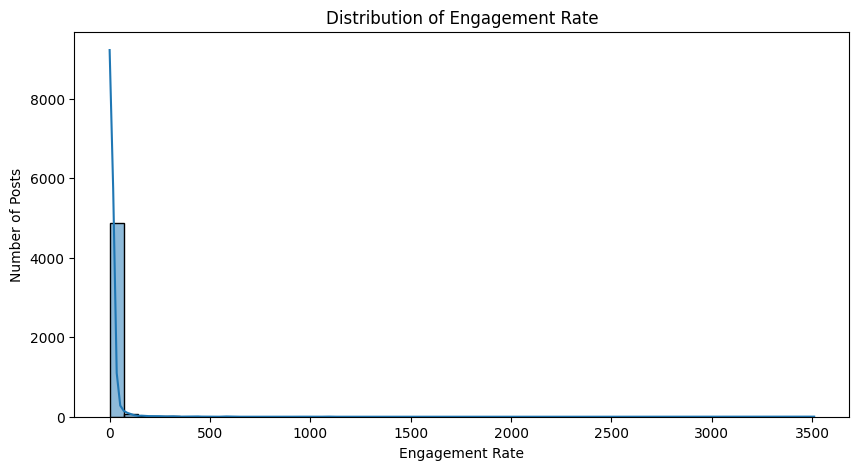

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Engagement_Rate"], bins=50, kde=True)
plt.title("Distribution of Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Number of Posts")
plt.show()

## 11. EDA — Engagement by Platform



This boxplot compares engagement rates across platforms. It shows the median, spread, and outliers for each platform. Because there are many extreme values, I avoid claiming that one platform is universally the best.

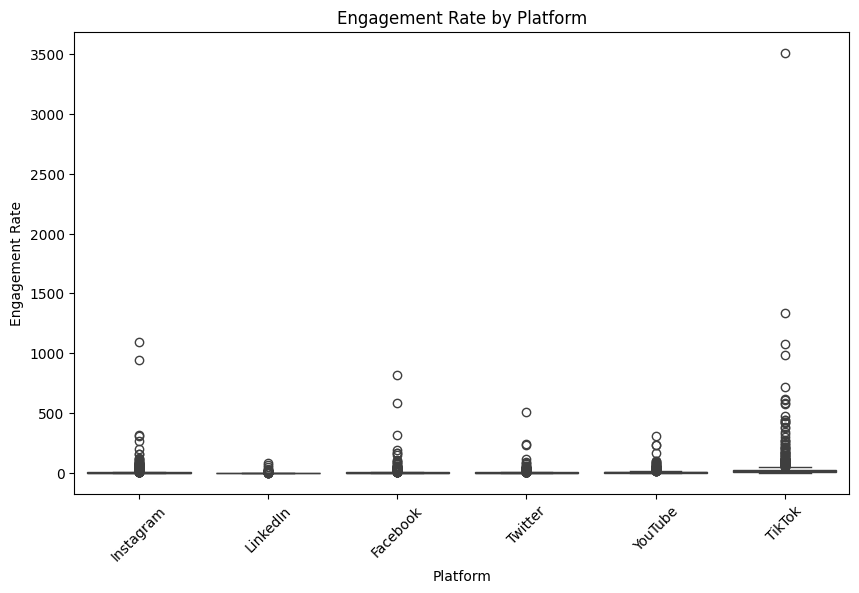

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Platform", y="Engagement_Rate")
plt.title("Engagement Rate by Platform")
plt.xlabel("Platform")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45)
plt.show()

## 12. EDA — Engagement by Content Type



This boxplot compares engagement across content types. Several content types contain extreme values, showing that engagement varies substantially from post to post.

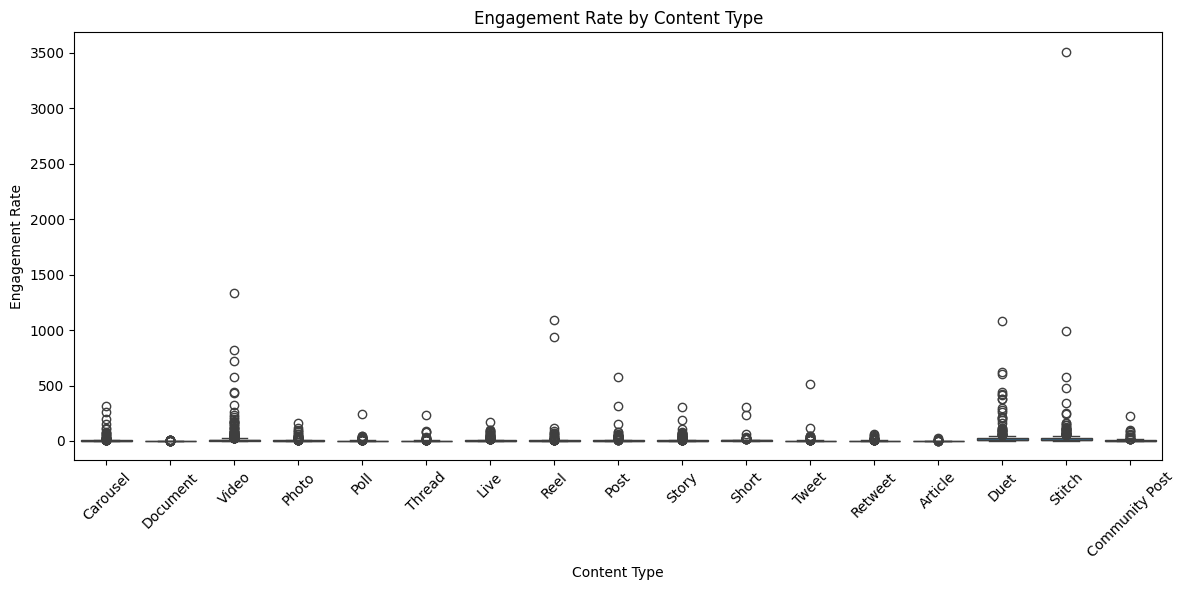

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Content_Type", y="Engagement_Rate")
plt.title("Engagement Rate by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. EDA — Engagement by Sentiment



This graph compares engagement across positive, negative, and neutral sentiment. Positive posts contain some of the highest extreme values, but sentiment alone does not explain engagement.

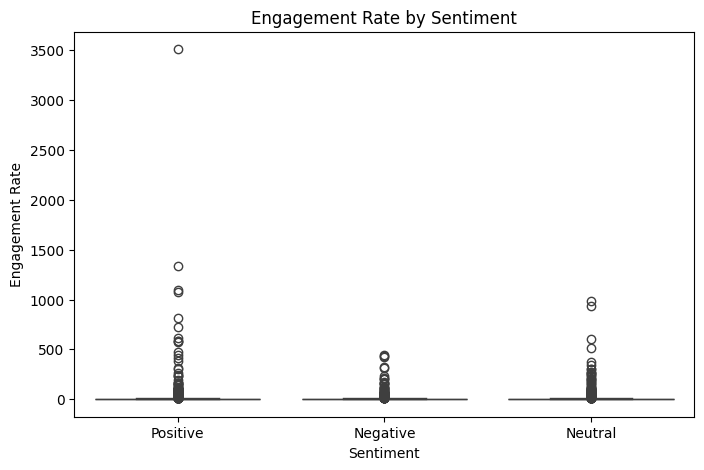

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Sentiment", y="Engagement_Rate")
plt.title("Engagement Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Engagement Rate")
plt.show()

## 14. EDA — Engagement by Influencer Tier



This graph compares influencer tiers. The groups have different engagement distributions, and the Nano tier has a relatively higher median and wider spread in this dataset. This makes influencer tier a useful candidate feature.

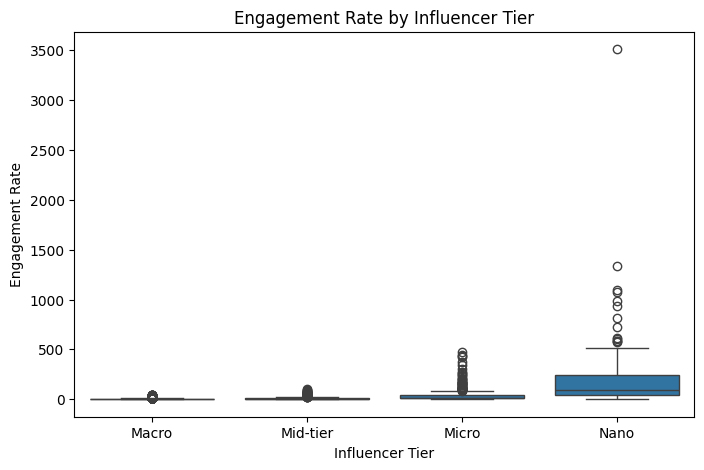

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Influencer_Tier", y="Engagement_Rate")
plt.title("Engagement Rate by Influencer Tier")
plt.xlabel("Influencer Tier")
plt.ylabel("Engagement Rate")
plt.show()

## 15. EDA — Average Engagement by Posting Hour



This line graph shows the average engagement rate at each hour of the day. The averages vary across hours, suggesting that posting time may contain useful information. These are patterns in this dataset, not universal social-media rules.

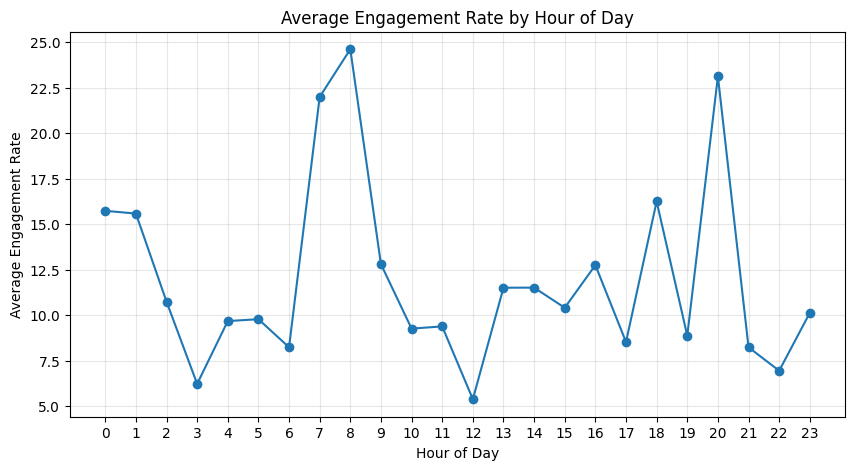

In [ ]:
hourly_engagement = df.groupby("Hour_of_Day")["Engagement_Rate"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_engagement.index, hourly_engagement.values, marker="o")
plt.title("Average Engagement Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Engagement Rate")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.show()

## 16. EDA — Correlation Heatmap



The heatmap shows linear correlations between numerical variables. Likes have the strongest positive correlation with Engagement Rate among these variables, while Follower Count has a negative correlation of about -0.21. Correlation does not prove causation. I will exclude post-performance variables such as likes and views from the model inputs to reduce data leakage.

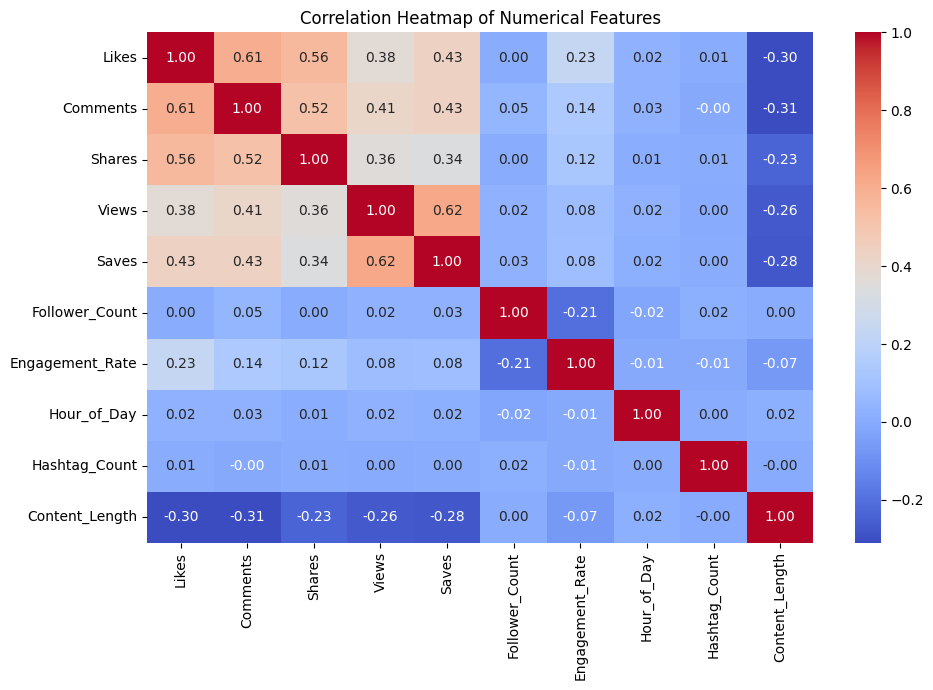

In [ ]:
numeric_columns = [
    "Likes", "Comments", "Shares", "Views", "Saves",
    "Follower_Count", "Engagement_Rate", "Hour_of_Day",
    "Hashtag_Count", "Content_Length"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

# 17. Machine Learning Preparation

### Target
The target variable is **Engagement_Rate**.

### Leakage control
I exclude **Likes, Comments, Shares, Views, and Saves** from the model inputs because they are post-performance measures. I also exclude **Post_ID** because it is only an identifier. Timestamp is replaced by useful time-based features created earlier.

## 18. Select Features and Target



I select 14 input features and separate them from the target. I deliberately exclude post-performance measures such as likes, comments, shares, views, and saves to reduce data leakage.

In [ ]:
features = [
    "Platform", "Content_Type", "Category", "Follower_Count",
    "Hour_of_Day", "Day_of_Week", "Hashtag_Count", "Content_Length",
    "Sentiment", "Influencer_Tier", "Has_Media", "Is_Verified",
    "Post_Month", "Is_Weekend"
]

X = df[features].copy()
y = df["Engagement_Rate"].copy()

print("Number of input features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of input features: 14
X shape: (5000, 14)
y shape: (5000,)


## 19. Identify Feature Types



I separate the inputs into categorical, numerical, and Boolean features. This allows me to apply the correct preprocessing to each type.

In [ ]:
categorical_features = [
    "Platform", "Content_Type", "Category",
    "Day_of_Week", "Sentiment", "Influencer_Tier"
]

numerical_features = [
    "Follower_Count", "Hour_of_Day",
    "Hashtag_Count", "Content_Length", "Post_Month"
]

boolean_features = ["Has_Media", "Is_Verified", "Is_Weekend"]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)
print("Boolean features:", boolean_features)

Categorical features: ['Platform', 'Content_Type', 'Category', 'Day_of_Week', 'Sentiment', 'Influencer_Tier']
Numerical features: ['Follower_Count', 'Hour_of_Day', 'Hashtag_Count', 'Content_Length', 'Post_Month']
Boolean features: ['Has_Media', 'Is_Verified', 'Is_Weekend']


## 20. Train-Test Split



I divide the data into 80 percent training data and 20 percent testing data. The training data is used to learn patterns, while the test data is kept separate for evaluation on unseen records.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (4000, 14)
Testing set: (1000, 14)


## 21. Preprocessing Pipeline



Numerical features are standardized, categorical features are one-hot encoded, and Boolean features are passed through unchanged. The ColumnTransformer applies the appropriate preprocessing to each group.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bool", "passthrough", boolean_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 22. Build the Random Forest Regression Model



I choose Random Forest Regression because Engagement Rate is continuous, making this a regression problem. Random Forest combines many decision trees and can learn nonlinear relationships between the features and the target.

In [ ]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest Regression model created successfully!")

Random Forest Regression model created successfully!


## 23. Train the Model


The fit function trains the Random Forest using the training data. The model learns patterns between the selected features and engagement rate.

In [ ]:
model.fit(X_train, y_train)
print("Model training completed successfully!")

Model training completed successfully!


## 24. Generate Predictions



I use the trained model to predict Engagement Rate for the unseen test data. These predictions are generated from patterns learned during training.

In [ ]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(np.round(y_pred[:10], 4))

First 10 predictions:
[ 1.2084  1.1571  8.1218  1.037  23.7644  1.5558  1.3886 61.5502  7.7797
  2.2632]


## 25. Evaluate the Model


I use R-squared, MAE, and RMSE. R-squared measures the proportion of variation explained by the model. MAE is the average absolute prediction error. RMSE also measures error but penalizes large errors more heavily. Because the dataset contains extreme engagement rates, RMSE is much larger than MAE.

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Evaluation Results")
print("------------------------")
print("R² Score:", round(r2, 4))
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))

Model Evaluation Results
------------------------
R² Score: 0.3519
MAE: 8.0668
RMSE: 98.6705


## 26. Actual vs Predicted Values



This scatter plot compares actual and predicted engagement rates. The diagonal line represents perfect predictions. Points closer to that line indicate better predictions. The extreme observations are difficult for the model to predict accurately.

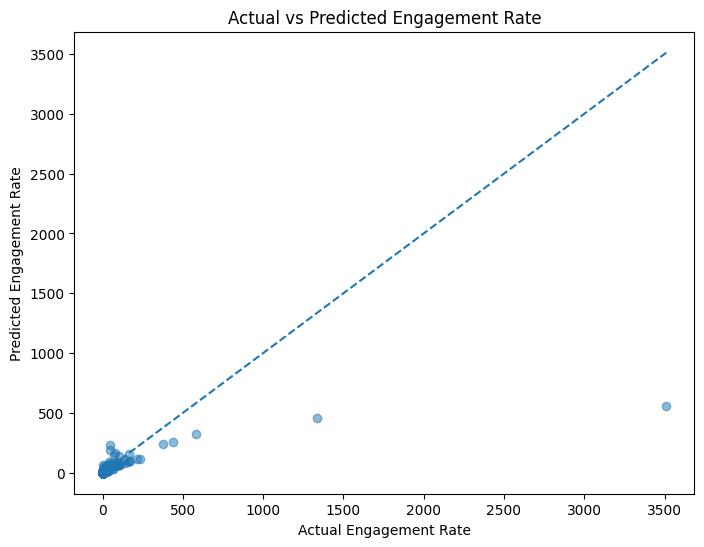

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.title("Actual vs Predicted Engagement Rate")
plt.xlabel("Actual Engagement Rate")
plt.ylabel("Predicted Engagement Rate")
plt.show()

## 27. Feature Importance



I extract feature importance values from the trained Random Forest. These values show which transformed input features were most useful to the model. Feature importance does not prove that a feature causes engagement.

In [ ]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("Top 15 features:")
display(importance_df.head(15))

Top 15 features:


,Feature,Importance
0,num__Follower_Count,0.581857
8,cat__Platform_TikTok,0.185213
3,num__Content_Length,0.076786
4,num__Post_Month,0.021213
37,cat__Category_Sports,0.017460
2,num__Hashtag_Count,0.015961
1,num__Hour_of_Day,0.015826
20,cat__Content_Type_Reel,0.010765
10,cat__Platform_YouTube,0.006923
47,cat__Sentiment_Negative,0.004784


## 28. Top 10 Feature Importance Visualization

This chart displays the ten most important transformed features. In the completed run used during development, Follower Count was the strongest feature, followed by TikTok and Content Length. The notebook will calculate the values again when it is run.

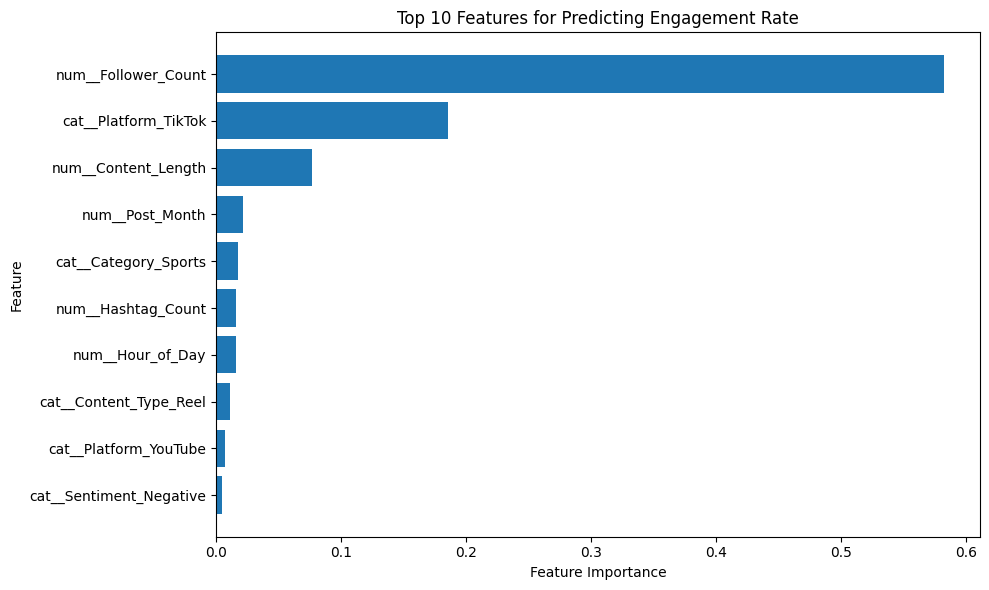

In [ ]:
top_features = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Features for Predicting Engagement Rate")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 29. Final Conclusion

This project analyzed 5,000 social-media posts and developed a Random Forest Regression model to predict Engagement Rate.

The dataset was inspected for structure, missing values, duplicates, and data types. Timestamp was converted to date-time and used to create Post Month and Is Weekend. Exploratory analysis showed a strongly right-skewed engagement-rate distribution and variation across platforms, content types, sentiment, influencer tiers, and posting hours.

For machine learning, post-performance variables such as Likes, Comments, Shares, Views, and Saves were excluded from the model inputs to reduce data leakage. Categorical variables were one-hot encoded, numerical variables were standardized, and Boolean variables were passed through unchanged.

The data was divided into 80% training and 20% testing sets. Random Forest Regression was selected because the target is continuous and the algorithm can model nonlinear relationships.

The final model performance is reported by the R², MAE, and RMSE values printed in the evaluation section above. The exact values should be taken from the fresh run of this notebook because the corrected preprocessing now includes the Boolean features that were unintentionally dropped in the earlier notebook.

The model provides a useful baseline, but its performance is affected by the highly skewed target and extreme values. Future improvements could include hyperparameter tuning, additional relevant features, alternative regression algorithms, and careful treatment of extreme observations.

# 30. Final Video Closing



To conclude, this project used a complete machine-learning pipeline to analyze social-media data and predict engagement rate. I performed data inspection and cleaning, created new features, carried out exploratory data analysis, prepared the data using encoding and scaling, trained a Random Forest regression model, and evaluated it using R-squared, MAE, and RMSE.

The final model performance is represented by the R-squared, MAE, and RMSE values shown in my evaluation output. I also analyzed feature importance to understand which inputs were most useful to the model.

The main limitation is the highly skewed engagement-rate distribution and the presence of extreme values. Overall, this project demonstrates the complete machine-learning workflow from raw social-media data to prediction and evaluation.